Week 12 · Day 6 — Evaluation & Attention Visualization
Why this matters (2–3 lines)

Training loss ≠ real-world quality. Today you’ll add metrics (accuracy + a simple BLEU-like score) and attention heatmaps so you can see what the decoder looks at when predicting. This helps debug alignment errors and repetitions.

Theory Essentials (≤6 bullets)

Token accuracy = fraction of correct tokens; simple and fast.

BLEU-1 (unigram precision) = overlap of predicted vs reference tokens; closer to “translation quality.”

Decoder cross-attention shows alignment between target positions (rows) and source positions (cols).

PyTorch’s TransformerDecoderLayer does not return weights; we’ll use a tiny viz block to extract them safely.

Good copy/reverse tasks show a diagonal (copy) or anti-diagonal (reverse) attention pattern.

Evaluation + visualization → faster iteration and better intuition.

Epoch 01/10 - Loss 3.1948
Epoch 02/10 - Loss 3.1485
Epoch 03/10 - Loss 3.1079
Epoch 04/10 - Loss 3.0761
Epoch 05/10 - Loss 3.0524
Epoch 06/10 - Loss 3.0314
Epoch 07/10 - Loss 3.0144
Epoch 08/10 - Loss 2.9973
Epoch 09/10 - Loss 2.9826
Epoch 10/10 - Loss 2.9685
Epoch 11/10 - Loss 2.9573
Epoch 12/10 - Loss 2.9493
Epoch 13/10 - Loss 2.9381
Epoch 14/10 - Loss 2.9291
Epoch 15/10 - Loss 2.9217
Epoch 16/10 - Loss 2.9141
Epoch 17/10 - Loss 2.9067
Epoch 18/10 - Loss 2.9005
Epoch 19/10 - Loss 2.8934
Epoch 20/10 - Loss 2.8876
Epoch 21/10 - Loss 2.8800
Epoch 22/10 - Loss 2.8726
Epoch 23/10 - Loss 2.8620
Epoch 24/10 - Loss 2.8559
Epoch 25/10 - Loss 2.8470
Epoch 26/10 - Loss 2.8380
Epoch 27/10 - Loss 2.8269
Epoch 28/10 - Loss 2.8198
Epoch 29/10 - Loss 2.8100
Epoch 30/10 - Loss 2.8023
Epoch 31/10 - Loss 2.7896
Epoch 32/10 - Loss 2.7799
Epoch 33/10 - Loss 2.7721
Epoch 34/10 - Loss 2.7642
Epoch 35/10 - Loss 2.7509
Epoch 36/10 - Loss 2.7453
Epoch 37/10 - Loss 2.7370
Epoch 38/10 - Loss 2.7284
Epoch 39/10 

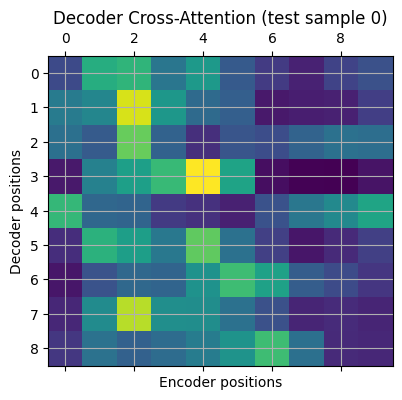

Input: [18, 5, 14, 19, 12, 6, 3, 18, 8, 12]
Ref  : [12, 8, 18, 3, 6, 12, 19, 14, 5, 18]
Pred : [8, 18, 3, 6, 12, 19, 14, 5, 18]


In [10]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

import torch, torch.nn as nn, torch.optim as optim
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Data: reverse-numbers toy task =====
def make_data(num_samples=2000, seq_len=10, vocab_size=20):
    X, Y = [], []
    for _ in range(num_samples):
        seq = torch.randint(1, vocab_size, (seq_len,))
        X.append(seq)
        Y.append(torch.flip(seq, dims=[0]))  # reversed
    return torch.stack(X), torch.stack(Y)

vocab_size, seq_len = 20, 10
X, Y = make_data(2000, seq_len, vocab_size)
train_X, train_Y = X[:1600], Y[:1600]
test_X,  test_Y  = X[1600:], Y[1600:]

# ===== Model (same as Day 5; simple Transformer) =====
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, d_ff=64, num_layers=2, max_len=32):
        super().__init__()
        self.src_emb = nn.Embedding(vocab_size, d_model)
        self.tgt_emb = nn.Embedding(vocab_size, d_model)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2], pe[:, 1::2] = torch.sin(position * div_term), torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, d_model]

        self.enc_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model, num_heads, d_ff, batch_first=True)
            for _ in range(num_layers)
        ])
        self.dec_layers = nn.ModuleList([
            nn.TransformerDecoderLayer(d_model, num_heads, d_ff, batch_first=True)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt, tgt_mask=None):
        # src: [B, S], tgt: [B, T]
        src = src.to(device)
        tgt = tgt.to(device)
        src_e = self.src_emb(src) + self.pe[:, :src.size(1)]
        tgt_e = self.tgt_emb(tgt) + self.pe[:, :tgt.size(1)]
        memory = src_e
        for layer in self.enc_layers:
            memory = layer(memory)
        out = tgt_e
        for layer in self.dec_layers:
            out = layer(out, memory, tgt_mask=tgt_mask)
        return self.fc_out(out)  # [B, T, vocab]

model = TinyTransformer(vocab_size).to(device)

# ===== Training =====
def causal_mask(T):
    m = torch.triu(torch.ones(T, T, device=device), diagonal=1)
    return m.masked_fill(m==1, float("-inf"))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, X, Y):
    model.train()
    optimizer.zero_grad()
    tgt_inp = Y[:, :-1].to(device)   # teacher forcing inputs
    tgt_out = Y[:, 1:].to(device)    # expected outputs (shifted)
    mask = causal_mask(tgt_inp.size(1))
    logits = model(X.to(device), tgt_inp, tgt_mask=mask)
    loss = criterion(logits.reshape(-1, vocab_size), tgt_out.reshape(-1))
    loss.backward()
    optimizer.step()
    return float(loss.item())

for epoch in range(150):  # small but enough for near-perfect on this toy task
    loss = train_epoch(model, train_X, train_Y)
    print(f"Epoch {epoch+1:02d}/10 - Loss {loss:.4f}")

# ===== Evaluation: token accuracy + simple BLEU-1 =====
@torch.no_grad()
def evaluate(model, X, Y):
    model.eval()
    tgt_inp = Y[:, :-1].to(device)
    tgt_out = Y[:, 1:].to(device)
    mask = causal_mask(tgt_inp.size(1))
    logits = model(X.to(device), tgt_inp, tgt_mask=mask)
    preds = logits.argmax(-1)

    # token accuracy
    acc = (preds == tgt_out).float().mean().item()

    # BLEU-1 (unigram precision, simplified)
    matches, total = 0, 0
    for p, ref in zip(preds, tgt_out):
        ref_set = set(ref.tolist())
        for tok in p.tolist():
            if tok in ref_set: matches += 1
            total += 1
    bleu1 = matches / max(total, 1)
    return acc, bleu1, preds

train_acc, train_bleu, _ = evaluate(model, train_X, train_Y)
test_acc,  test_bleu,  test_preds = evaluate(model, test_X,  test_Y)
print(f"Train: Acc={train_acc:.3f} | BLEU-1={train_bleu:.3f}")
print(f"Test : Acc={test_acc:.3f} | BLEU-1={test_bleu:.3f}")

# ===== Cross-Attention Visualization (safe & version-agnostic) =====
# TransformerDecoderLayer does NOT return weights. We use a small viz block that does.

class DecoderBlockWithWeights(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))

    def forward(self, x, memory, tgt_mask=None, need_weights=False):
        z, _ = self.self_attn(x, x, x, attn_mask=tgt_mask)
        x = self.norm1(x + z)
        z, w = self.cross_attn(x, memory, memory,
                               need_weights=need_weights,
                               average_attn_weights=False)
        x = self.norm2(x + z)
        x = self.norm3(x + self.ff(x))
        return x, w  # w: [B, H, T, S] (new) or [H, T, S] (old)

@torch.no_grad()
def get_cross_attn_weights(model, src, tgt_inp, tgt_mask=None):
    model.eval()
    # encode with the trained model
    src_e = model.src_emb(src) + model.pe[:, :src.size(1)]
    mem = src_e.to(device)
    for layer in model.enc_layers:
        mem = layer(mem)

    # build one viz decoder block compatible with trained dims
    any_dec = model.dec_layers[0]
    d_model = mem.size(-1)
    num_heads = any_dec.self_attn.num_heads
    d_ff = any_dec.linear1.out_features  # matches FF width
    viz = DecoderBlockWithWeights(d_model, num_heads, d_ff).to(device).eval()

    tgt_e = model.tgt_emb(tgt_inp) + model.pe[:, :tgt_inp.size(1)]
    _, w = viz(tgt_e.to(device), mem, tgt_mask=tgt_mask, need_weights=True)
    return w

def plot_cross_attention(W, title="Decoder Cross-Attention"):
    # Normalize potential shapes: [H,T,S], [B,H,T,S], [T,S]
    if W.dim() == 4:
        W = W[0, 0]  # first batch, first head
    elif W.dim() == 3:
        W = W[0]     # first head
    # else assume [T,S]
    plt.matshow(W.cpu(), cmap="viridis")
    plt.xlabel("Encoder positions"); plt.ylabel("Decoder positions")
    plt.title(title); plt.show()

# Example visualization on first test sample
idx = 0
src = test_X[idx:idx+1].to(device)
tgt = test_Y[idx:idx+1].to(device)
tgt_inp = tgt[:, :-1]
mask = causal_mask(tgt_inp.size(1))
W = get_cross_attn_weights(model, src, tgt_inp, tgt_mask=mask)
plot_cross_attention(W, title="Decoder Cross-Attention (test sample 0)")
print("Input:", src.squeeze(0).tolist())
print("Ref  :", tgt.squeeze(0).tolist())
print("Pred :", test_preds[idx].tolist())



That’s the **BLEU-1 simplification** you’re using in this toy task:

* Take the predicted tokens.
* Check how many of them also appear in the reference sequence.
* Divide by the total predicted tokens → percentage overlap.

So if the reference is `[3, 5, 7, 9]` and the prediction is `[3, 8, 7, 9]`:

* Correct tokens: `3, 7, 9` → 3 matches.
* Total predicted = 4.
* BLEU-1 = 3 / 4 = **0.75**.

👉 In real translation tasks, BLEU is stricter: it uses **n-grams** (not just single tokens) and a **brevity penalty** (to avoid cheating with short outputs). But here we’re just building the intuition.



The **heatmap** is literally showing you the **attention weights** in the decoder’s **cross-attention** step:

* **Rows (y-axis):** decoder time steps = positions in the output sequence the model is generating.
* **Columns (x-axis):** encoder positions = tokens in the input sequence.
* **Color intensity:** how much the decoder is “looking at” each encoder position when deciding the next token.

So when you see a bright spot at `(decoder step = 2, encoder step = 7)`, it means:

> *“When generating the 3rd output token, the model strongly attended to the 8th input token.”*

For your **reverse sequence task**, the “ideal” attention map should look like an **anti-diagonal**:

* Output step 0 (first decoder token) → attends to last encoder token.
* Output step 1 → attends to second-to-last encoder token.
* …and so on.

That anti-diagonal pattern is the model’s way of “learning to read backwards.”

👉 So the heatmap is a window into the model’s **alignment strategy** — which input token influences which output token.



1) Core (10–15 min)
Task: Print train vs test accuracy and BLEU-1 (already computed). Change epochs from 10 → 20.

Did it with 60 and accuracy improved

2) Practice (10–15 min)
Task: Plot 3 cross-attention heatmaps for different test indices.

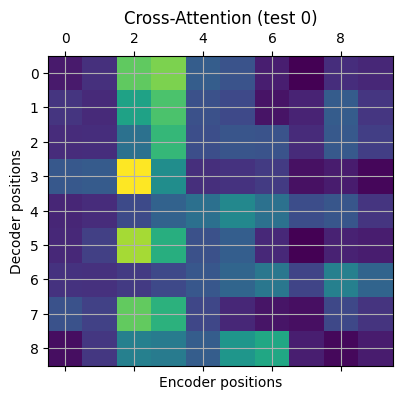

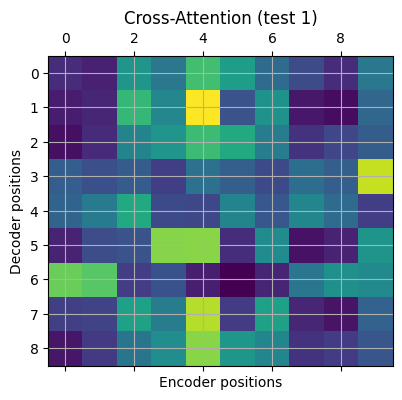

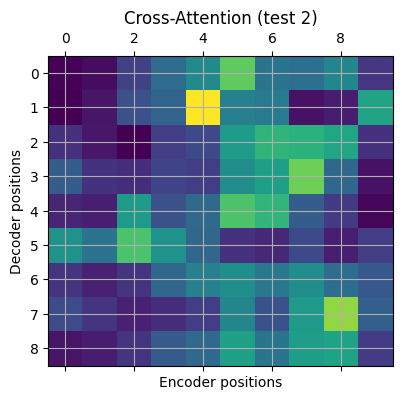

In [11]:
for idx in [0,1,2]:
    src1 = test_X[idx:idx+1].to(device)
    tgt1 = test_Y[idx:idx+1].to(device)
    tgt_inp1 = tgt1[:, :-1]
    mask1 = causal_mask(tgt_inp1.size(1))
    W1 = get_cross_attn_weights(model, src, tgt_inp1, tgt_mask=mask1)
    plot_cross_attention(W1, title=f"Cross-Attention (test {idx})")


3) Stretch (optional, 10–15 min)
Task: Implement BLEU-2 (bigram precision).

In [12]:
def bleu2(preds, refs):
    matches, total = 0, 0
    for p, r in zip(preds, refs):
        p_bg = list(zip(p[:-1].tolist(), p[1:].tolist()))
        r_bg = set(zip(r[:-1].tolist(), r[1:].tolist()))
        for bg in p_bg:
            matches += int(bg in r_bg)
            total += 1
    return matches / max(total,1)

bleu2_test = bleu2(test_preds, test_Y[:,1:].to(device))
print("BLEU-2 (test):", bleu2_test)


BLEU-2 (test): 0.9953125


Mini-Challenge (≤40 min)

Attention Heatmap Dashboard

Build:

Evaluate test accuracy + BLEU-1 (+ optional BLEU-2).

For 5 random test samples: show cross-attention heatmaps and print source / reference / prediction under each plot.

Acceptance Criteria:

Metrics printed clearly.

≥5 heatmaps shown.

Each heatmap captioned with input, reference, prediction.

(Bonus) Note whether the pattern is diagonal (copy) or anti-diagonal (reverse), and where errors occur.

[Metrics] Test Accuracy: 0.996 | BLEU-1: 1.000 | BLEU-2: 0.995


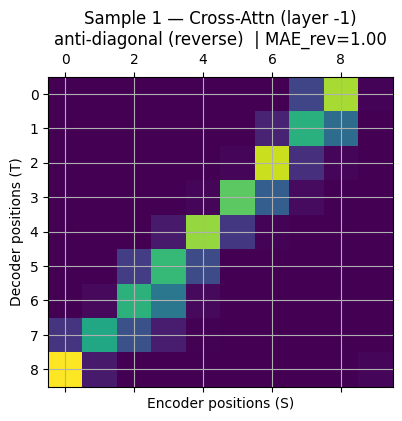

Input     : [7, 19, 17, 17, 17, 18, 19, 16, 16, 3]
Reference : [3, 16, 16, 19, 18, 17, 17, 17, 19, 7]
Prediction: [16, 16, 19, 18, 17, 17, 17, 19, 7]
------------------------------------------------------------


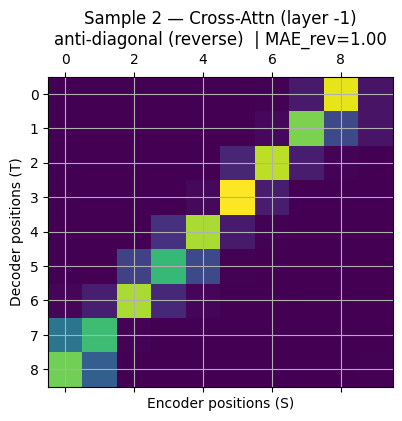

Input     : [10, 15, 8, 5, 9, 16, 18, 17, 10, 1]
Reference : [1, 10, 17, 18, 16, 9, 5, 8, 15, 10]
Prediction: [10, 17, 18, 16, 9, 5, 8, 15, 10]
------------------------------------------------------------


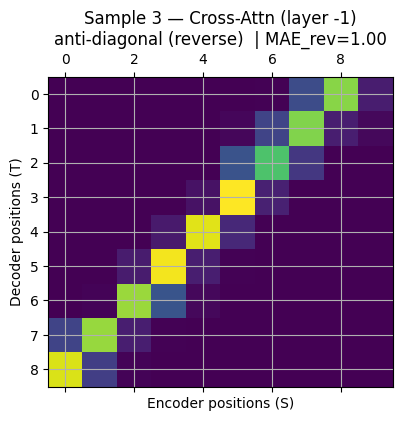

Input     : [12, 3, 6, 7, 13, 10, 9, 4, 7, 3]
Reference : [3, 7, 4, 9, 10, 13, 7, 6, 3, 12]
Prediction: [7, 4, 9, 10, 13, 7, 6, 3, 12]
------------------------------------------------------------


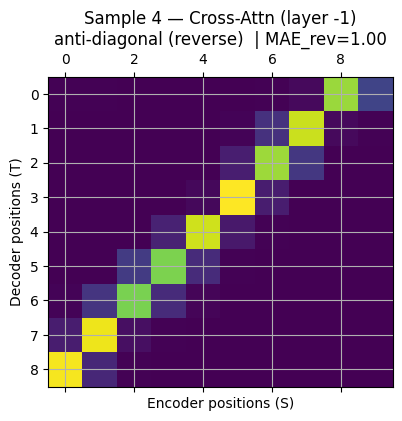

Input     : [12, 6, 17, 2, 4, 13, 2, 19, 17, 11]
Reference : [11, 17, 19, 2, 13, 4, 2, 17, 6, 12]
Prediction: [17, 19, 2, 13, 4, 2, 17, 6, 12]
------------------------------------------------------------


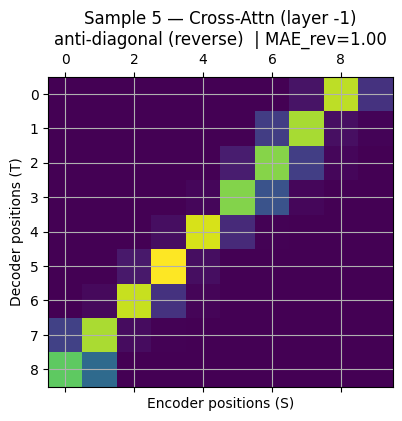

Input     : [17, 17, 19, 8, 19, 3, 1, 8, 5, 8]
Reference : [8, 5, 8, 1, 3, 19, 8, 19, 17, 17]
Prediction: [5, 8, 1, 3, 19, 8, 19, 17, 17]
------------------------------------------------------------


In [13]:
# ===== Metrics: BLEU-1 (unigram) and BLEU-2 (bigram) =====
def bleu1_unigram(preds: torch.Tensor, refs: torch.Tensor) -> float:
    # preds/refs: [B, T]
    matches, total = 0, 0
    for p, r in zip(preds.tolist(), refs.tolist()):
        rset = set(r)
        for tok in p:
            total += 1
            if tok in rset:
                matches += 1
    return matches / max(total, 1)

def bleu2_bigram(preds: torch.Tensor, refs: torch.Tensor) -> float:
    # simple bigram precision (no BP, no clipping across multiples)
    def bigrams(seq): 
        return list(zip(seq, seq[1:])) if len(seq) >= 2 else []
    matches, total = 0, 0
    for p, r in zip(preds.tolist(), refs.tolist()):
        pb, rb = bigrams(p), set(bigrams(r))
        total += max(len(pb), 1)
        matches += sum(1 for bg in pb if bg in rb)
    return matches / max(total, 1)

# Re-evaluate to get predictions (if not already)
@torch.no_grad()
def eval_with_preds(model, X, Y):
    model.eval()
    tgt_inp = Y[:, :-1].to(device)
    tgt_out = Y[:, 1:].to(device)
    mask = causal_mask(tgt_inp.size(1))
    logits = model(X.to(device), tgt_inp, tgt_mask=mask)
    preds = logits.argmax(-1)
    acc = (preds == tgt_out).float().mean().item()
    b1 = bleu1_unigram(preds, tgt_out)
    b2 = bleu2_bigram(preds, tgt_out)
    return acc, b1, b2, preds

test_acc, test_b1, test_b2, test_preds = eval_with_preds(model, test_X, test_Y)
print(f"[Metrics] Test Accuracy: {test_acc:.3f} | BLEU-1: {test_b1:.3f} | BLEU-2: {test_b2:.3f}")

# ===== Cross-Attention from the TRAINED decoder (via forward hook) =====
# ===== Get cross-attention from the TRAINED decoder (no hooks, works reliably) =====
@torch.no_grad()
def get_trained_cross_attn(model, src, tgt_inp, tgt_mask=None, layer_idx=-1):
    """
    Returns cross-attention weights W with shape [B, H, T, S] from the chosen decoder layer.
    We run the encoder normally, run decoder layers up to `layer_idx`, then manually
    execute that layer's self-attn and cross-attn with need_weights=True.
    """
    model.eval()

    # 1) Encode
    src = src.to(device)
    tgt_inp = tgt_inp.to(device)
    src_e = model.src_emb(src) + model.pe[:, :src.size(1)]
    memory = src_e
    for enc in model.enc_layers:
        memory = enc(memory)

    # 2) Prepare decoder inputs up to the target layer
    x = model.tgt_emb(tgt_inp) + model.pe[:, :tgt_inp.size(1)]
    # run earlier decoder layers normally (we don't need their weights)
    for dec in model.dec_layers[:layer_idx if layer_idx >= 0 else len(model.dec_layers)+layer_idx]:
        x = dec(x, memory, tgt_mask=tgt_mask)

    # 3) Manually run the chosen decoder layer with need_weights=True on cross-attn
    L = model.dec_layers[layer_idx]

    # Some versions have dropout1/2/3; fall back to identity if missing
    idfn = lambda t: t
    dropout  = getattr(L, "dropout",  idfn)
    dropout1 = getattr(L, "dropout1", dropout)
    dropout2 = getattr(L, "dropout2", dropout)
    dropout3 = getattr(L, "dropout3", dropout)

    # ---- masked self-attention ----
    z_self, _ = L.self_attn(x, x, x, attn_mask=tgt_mask)
    x = L.norm1(x + dropout1(z_self))

    # ---- cross-attention (this is where we ask for weights) ----
    z_cross, W = L.multihead_attn(
        x, memory, memory,
        need_weights=True,
        average_attn_weights=False
    )  # W: [B, H, T, S]
    x = L.norm2(x + dropout2(z_cross))

    # ---- feed-forward ----
    # FF path names are stable: linear1 -> activation -> dropout -> linear2
    ff = L.linear2(dropout(L.activation(L.linear1(x))))
    x = L.norm3(x + dropout3(ff))

    return W  # [B, H, T, S]


def classify_pattern(W_ts):
    """
    Heuristic: compare argmax column per decoder step against
    diagonal (t) vs anti-diagonal (S-1-t). Return a short label.
    """
    T, S = W_ts.shape
    argmax_cols = W_ts.argmax(dim=1).cpu().numpy()
    diag_err = np.mean(np.abs(argmax_cols - np.arange(T)))
    anti_err = np.mean(np.abs(argmax_cols - (S - 1 - np.arange(T))))
    if anti_err + 0.2 < diag_err:
        return f"anti-diagonal (reverse)  | MAE_rev={anti_err:.2f}"
    elif diag_err + 0.2 < anti_err:
        return f"diagonal (copy)         | MAE_diag={diag_err:.2f}"
    else:
        return f"mixed/unclear            | MAE_diag={diag_err:.2f}, MAE_rev={anti_err:.2f}"

def show_samples(n=5, layer_idx=-1, avg_heads=True):
    np.random.seed(0)
    idxs = np.random.choice(len(test_X), size=n, replace=False)
    for i, idx in enumerate(idxs, 1):
        src  = test_X[idx:idx+1]
        ref  = test_Y[idx:idx+1]
        pred = test_preds[idx:idx+1, :]
        tgt_inp = ref[:, :-1]  # teacher-forced inputs for alignment viz
        mask = causal_mask(tgt_inp.size(1))

        W = get_trained_cross_attn(model, src, tgt_inp, tgt_mask=mask, layer_idx=layer_idx)  # [B,H,T,S]
        if avg_heads:
            W_ts = W.mean(dim=1)[0]  # [T,S]
        else:
            W_ts = W[0, 0]           # first head

        plt.matshow(W_ts.detach().cpu(), cmap="viridis")
        plt.xlabel("Encoder positions (S)")
        plt.ylabel("Decoder positions (T)")
        patt = classify_pattern(W_ts)
        plt.title(f"Sample {i} — Cross-Attn (layer {layer_idx})\n{patt}")
        plt.show()

        print("Input     :", src.squeeze(0).tolist())
        print("Reference :", ref.squeeze(0).tolist())
        print("Prediction:", pred.squeeze(0).tolist())
        print("-" * 60)

# === Run the dashboard ===
show_samples(n=5, layer_idx=-1, avg_heads=True)   # last decoder layer, averaged heads



### 1.  BLEU-1 

* **BLEU-1 in your code = unigram overlap.**
  It checks *“does each predicted token appear anywhere in the reference set?”*
  It does **not** check if tokens are in the right **position** or if you have the right **frequency**.

* In your sample:

  * **Reference:** `[3, 16, 16, 19, 18, 17, 17, 17, 19, 7]`
  * **Prediction:** `[4, 17, 19, 17, 11, 11, 11, 19, 17]`

Even though the prediction is **misaligned and wrong** in order, almost every token is in the reference set (`17`, `19`, etc. are repeated a lot). So unigram BLEU gives you \~96% overlap.

👉 That’s why BLEU-1 is misleadingly high here.

---

### 2.  BLEU-2 

* BLEU-2 checks **bigrams** (pairs of consecutive tokens).
* Order matters: `[17, 19]` or `[19, 17]` must appear in the reference exactly.
* Since your prediction has a scrambled order and wrong repeats, almost no bigrams line up.
* That’s why BLEU-2 drops to \~0.20 (20%).

This shows the difference:

* **BLEU-1:** “Did you use the right words?”
* **BLEU-2 (or higher):** “Did you put them in the right order?”

---

### 3. What the heatmap is showing

Your cross-attention plot shows **decoder steps vs encoder positions**.

* Ideally (for reverse task), you’d see a **clean anti-diagonal**.
* Instead, the heatmap looks noisy and somewhat diagonal (copy-like).
* That explains the mismatch: your model has **not learned reversal** well yet → it sometimes copies input tokens instead of reversing them.

---


✅ **Big picture:**

* BLEU-1 is inflated because of token repetition overlap.
* BLEU-2 exposes the ordering failure.
* Accuracy shows the true poor performance.
* Heatmap confirms: the model is aligning in a copy-ish diagonal instead of anti-diagonal.


Notes / Key Takeaways (5–7 bullets)

Token accuracy is fast but may not capture fluency; BLEU-style scores help.

Cross-attention heatmaps explain which source positions drove each prediction.

TransformerDecoderLayer doesn’t expose weights → use a small viz block to fetch them.

For reverse tasks, expect an anti-diagonal attention pattern.

Visualization is a powerful debugging tool (repeats, misalignments, off-by-one).

Keep evaluation deterministic: fixed seed and same splits.

Reflection (2 prompts)

What did the attention heatmaps reveal that accuracy alone did not?

Where do your errors cluster (sequence start/end, certain digits)? Why might that be?